In [1]:
from __future__ import annotations

from collections import defaultdict
import math
import os
from pathlib import Path
import re
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import cv2
import numpy as np
from sklearn.cluster import KMeans
import supervision as sv
from tqdm import tqdm
import umap

from inference import get_model
from sports import TeamClassifier
from sports.football.annotators import draw_field, draw_points_on_field, draw_los_dotted, draw_paths_on_field, draw_receiver_mph_sep_labels
from sports.football.config import FootballFieldConfig
from src.config import VIDEO_DIR, INV_DIR, MAPS_DIR, DEBUG_DIR

[03/03/26 17:40:59] WARNING  Your inference package version 0.64.5 is out of date! Please upgrade to ]8;id=126726;file://d:\Downloads\nfl_player_detection\.venv\lib\site-packages\inference\core\__init__.py\__init__.py]8;;\:]8;id=640791;file://d:\Downloads\nfl_player_detection\.venv\lib\site-packages\inference\core\__init__.py#41\41]8;;\
                             version 1.0.3 of inference for the latest features and bug fixes by                   
                             running `pip install --upgrade inference`.                                            

ModelDependencyMissing: Your `inference` configuration does not support SAM model. Use pip install 'inference[sam]' to install missing requirements.To suppress this warning, set CORE_MODEL_SAM_ENABLED to False.
ModelDependencyMissing: Your `inference` configuration does not support SAM2 model. Use pip install 'inference[sam]' to install missing requirements.To suppress this warning, set CORE_MODEL_SAM2_ENABLED to False.
ModelDependencyMissing: Your `inference` configuration does not support SAM3 model. Install SAM3 dependencies and set CORE_MODEL_SAM3_ENABLED to True.
ModelDependencyMissing: Your `inference` configuration does not support Gaze Detection model. Use pip install 'inference[gaze]' to install missing requirements.To suppress this warning, set CORE_MODEL_GAZE_ENABLED to False.
ModelDependencyMissing: Your `inference` configuration does not support YoloWorld model. Use pip install 'inference[yolo-world]' to install missing requirements.To suppress this warning, set CORE_MODEL

In [2]:
FPS = 30

SOURCE_VIDEO_PATH = VIDEO_DIR / "passplay.mp4" # Replace passplay.mp4 WITH YOUR VIDEO PATH
VIDEO_PATH = VIDEO_DIR / "compressed videos" / f"{SOURCE_VIDEO_PATH.stem}{FPS}.mp4"

RF_API_KEY = os.getenv("ROBOFLOW_API_KEY")

!ffmpeg -y -loglevel error -i "{SOURCE_VIDEO_PATH}" -vf "fps={FPS}" -an "{VIDEO_PATH}"

PLAYER_DETECTION_MODEL = get_model(model_id="player-detection-h1a6d/1", api_key=RF_API_KEY)
PLAYER_DETECTION_MODEL_CONFIDENCE = 0.2
PLAYER_DETECTION_MODEL_IOU_THRESHOLD = 0.8

KEYPOINT_DETECTION_MODEL = get_model(model_id="nflfield/2", api_key=RF_API_KEY)
KEYPOINT_DETECTION_MODEL_CONFIDENCE = 0.5
KEYPOINT_DETECTION_MODEL_ANCHOR_CONFIDENCE = 0.4
KEYPOINT_DETECTION_MODEL_IOU_THRESHOLD = 0.05

LINE_DETECTION_MODEL = get_model(model_id="nflline2/5", api_key=RF_API_KEY)
LINE_DETECTION_MODEL_CONFIDENCE = 0.5
LINE_DETECTION_MODEL_ANCHOR_CONFIDENCE = 0.4
LINE_DETECTION_MODEL_IOU_THRESHOLD = 0.05

KEYPOINT_COLOR = sv.Color.from_hex("#FF1493")

Resolved model_id: player-detection-h1a6d/1, dataset_id: player-detection-h1a6d, version_id: 1


Resolved model_id: nflfield/2, dataset_id: nflfield, version_id: 2


Resolved model_id: nflline2/5, dataset_id: nflline2, version_id: 5


In [9]:
ALL_NFL_COLORS = {
    "Arizona Cardinals": "#97233F",
    "Atlanta Falcons": "#A71930",
    "Baltimore Ravens": "#241773",
    "Buffalo Bills": "#00338D",
    "Carolina Panthers": "#0085CA",
    "Chicago Bears": "#0B162A",
    "Cincinnati Bengals": "#FB4F14",
    "Cleveland Browns": "#311D00",
    "Dallas Cowboys": "#041E42",
    "Denver Broncos": "#FB4F14",
    "Detroit Lions": "#0076B6",
    "Green Bay Packers": "#203731",
    "Houston Texans": "#03202F",
    "Indianapolis Colts": "#002C5F",
    "Jacksonville Jaguars": "#006778",
    "Kansas City Chiefs": "#E31837",
    "Las Vegas Raiders": "#000000",
    "Los Angeles Chargers": "#0080C6",
    "Los Angeles Rams": "#003594",
    "Miami Dolphins": "#008E97",
    "Minnesota Vikings": "#4F2683",
    "New England Patriots": "#002244",
    "New Orleans Saints": "#D3BC8D",
    "New York Giants": "#0B2265",
    "New York Jets": "#125740",
    "Philadelphia Eagles": "#004C54",
    "Pittsburgh Steelers": "#FFB612",
    "San Francisco 49ers": "#AA0000",
    "Seattle Seahawks": "#002244",
    "Tampa Bay Buccaneers": "#D50A0A",
    "Tennessee Titans": "#0C2340",
    "Washington Commanders": "#5A1414"
}

# Define the teams playing in the video
TEAM_A = "New York Giants"
TEAM_B = "Las Vegas Raiders"

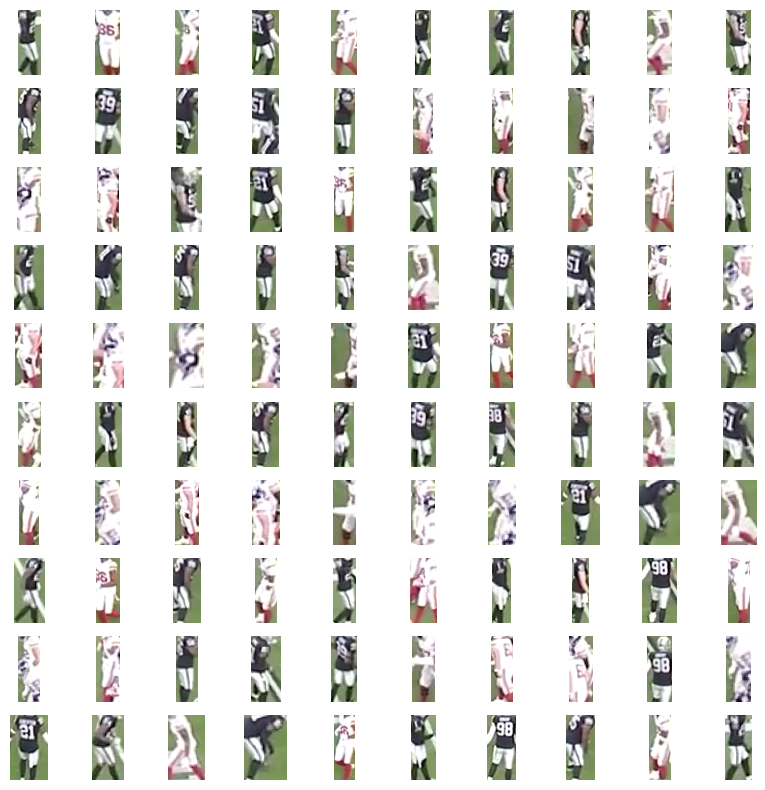

Embedding extraction: 54it [00:08,  6.73it/s]
Embedding extraction: 54it [00:07,  7.18it/s]


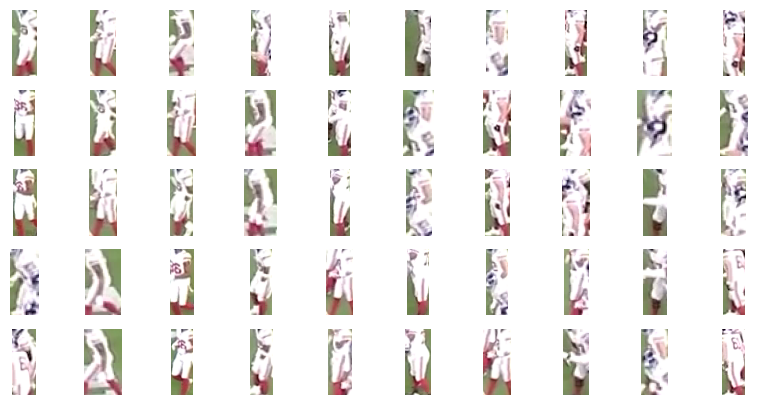

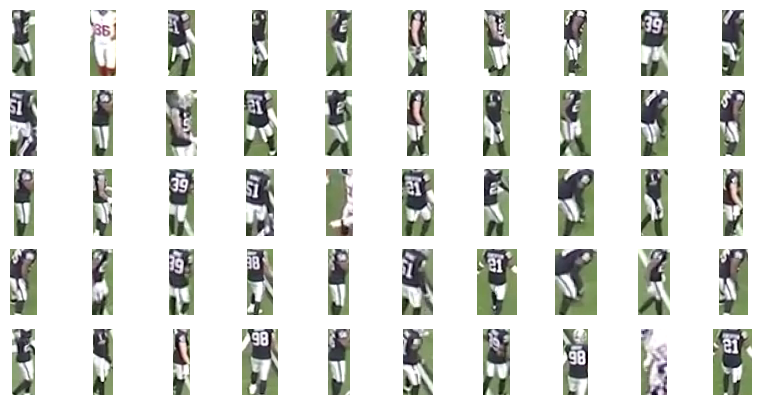

Embedding extraction: 1it [00:00,  8.93it/s]


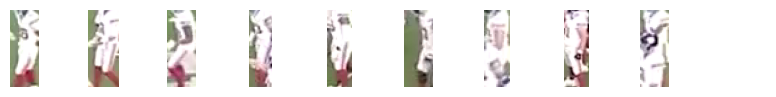

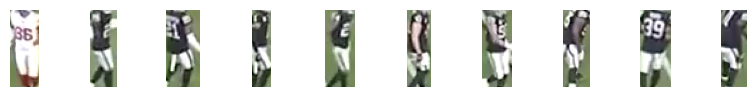

In [10]:
STRIDE = 7
PLAYER_CLASS_IDS = [0]

train_crops = []

frame_generator = sv.get_video_frames_generator(source_path=SOURCE_VIDEO_PATH, stride=STRIDE)

for frame in tqdm(frame_generator, desc="Collecting training crops"):
    result = PLAYER_DETECTION_MODEL.infer(
        frame,
        confidence=PLAYER_DETECTION_MODEL_CONFIDENCE,
        iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD,
        class_agnostic_nms=True
    )[0]

    detections = sv.Detections.from_inference(result)
    detections = detections[np.isin(detections.class_id, PLAYER_CLASS_IDS)]

    boxes = sv.scale_boxes(xyxy=detections.xyxy, factor=0.7)
    for box in boxes:
        train_crops.append(sv.crop_image(frame, box))

sv.plot_images_grid(
    images=train_crops[:100],
    grid_size=(10, 10),
    size=(10, 10)
)

team_classifier = TeamClassifier(device="cuda")

# make clustering stable across runs
team_classifier.reducer = umap.UMAP(n_components=3, random_state=42)
team_classifier.cluster_model = KMeans(n_clusters=2, random_state=42, n_init=10)

team_classifier.fit(train_crops)

train_teams = team_classifier.predict(train_crops)

train_team_0 = [crop for crop, team in zip(train_crops, train_teams) if team == 0]
train_team_1 = [crop for crop, team in zip(train_crops, train_teams) if team == 1]

sv.plot_images_grid(images=train_team_0[:50], grid_size=(5, 10), size=(10, 5))
sv.plot_images_grid(images=train_team_1[:50], grid_size=(5, 10), size=(10, 5))

# sanity check on a real VIDEO_PATH frame
frame_generator = sv.get_video_frames_generator(VIDEO_PATH)
frame = next(frame_generator)

result = PLAYER_DETECTION_MODEL.infer(
    frame,
    confidence=PLAYER_DETECTION_MODEL_CONFIDENCE,
    iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD,
    class_agnostic_nms=True
)[0]

detections = sv.Detections.from_inference(result)
detections = detections[np.isin(detections.class_id, PLAYER_CLASS_IDS)]

boxes = sv.scale_boxes(xyxy=detections.xyxy, factor=0.7)
frame_crops = [sv.crop_image(frame, box) for box in boxes]
frame_teams = np.array(team_classifier.predict(frame_crops))

frame_team_0 = [crop for crop, team in zip(frame_crops, frame_teams) if team == 0]
frame_team_1 = [crop for crop, team in zip(frame_crops, frame_teams) if team == 1]

sv.plot_images_grid(images=frame_team_0[:10], grid_size=(1, 10), size=(10, 1))
sv.plot_images_grid(images=frame_team_1[:10], grid_size=(1, 10), size=(10, 1))

TEAM_NAMES = {
    0: TEAM_A,
    1: TEAM_B
}

TEAM_COLORS = {
    TEAM_NAMES[0]: ALL_NFL_COLORS[TEAM_NAMES[0]],
    TEAM_NAMES[1]: ALL_NFL_COLORS[TEAM_NAMES[1]]
}

In [18]:
# Output paths
OUT_PLAYER_MAP = MAPS_DIR / f"{VIDEO_PATH.stem}-player_mapping{VIDEO_PATH.suffix}"
OUT_PLAYER_MAP_COMP = MAPS_DIR / f"{OUT_PLAYER_MAP.stem}-compressed{OUT_PLAYER_MAP.suffix}"

# Field config
config = FootballFieldConfig()

# Image conversion helper
def _to_bgr_uint8(img: np.ndarray) -> np.ndarray:
    if img is None:
        return np.zeros((720, 1280, 3), dtype=np.uint8)
    if not isinstance(img, np.ndarray):
        img = np.array(img)

    if img.dtype != np.uint8:
        img = np.nan_to_num(img)
        if img.size and img.max() <= 1.0:
            img = img * 255.0
        img = np.clip(img, 0, 255).astype(np.uint8)

    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    elif img.ndim == 3 and img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)
    elif img.ndim != 3 or img.shape[2] != 3:
        img = np.zeros((720, 1280, 3), dtype=np.uint8)

    return img

# Field canvas
field0 = _to_bgr_uint8(draw_field(config=config))
H, W = field0.shape[:2]
H += (H % 2)
W += (W % 2)

# Video info
video_info = sv.VideoInfo.from_video_path(VIDEO_PATH)
video_info.width = W
video_info.height = H
video_info.fps = FPS

# Team colors
team0_color = sv.Color.from_hex(TEAM_COLORS[TEAM_NAMES[0]])
team1_color = sv.Color.from_hex(TEAM_COLORS[TEAM_NAMES[1]])

# Player filters
MIN_AREA = 25
MIN_H = 16
AR_MIN, AR_MAX = 0.20, 3.5

# Number detection thresholds (uses your keypoint model values)
NUM_DET_CONF_MIN = KEYPOINT_DETECTION_MODEL_CONFIDENCE
NUM_KP_CONF_MIN = KEYPOINT_DETECTION_MODEL_ANCHOR_CONFIDENCE

STRIPE_NUM_DET_CONF_MIN = 0.25
STRIPE_NUM_KP_CONF_MIN = 0.20
STRIPE_VARIANT_EPS_RATIO = 0.005

# Line thresholds
LINE_DET_CONF_MIN = LINE_DETECTION_MODEL_CONFIDENCE
LINE_KP_CONF_MIN = LINE_DETECTION_MODEL_ANCHOR_CONFIDENCE
LINE_KP_CONF_MIN_23 = float(LINE_KP_CONF_MIN)
LINE_KP_CONF_MIN_14 = max(0.05, float(LINE_KP_CONF_MIN) - 0.4)

# Weighted Sideline Points
SIDELINE_WEIGHT = 1   # 4–10 typical
HASH_WEIGHT = 1
NUM_WEIGHT = 1

# Stripe settings
HALF_WIDTH_PX = 50.0
STRIPE_KEY_NAME = "num"

# Trackers
LINE_LOST_SECONDS = 0.8
LINE_LOST_BUFFER = max(1, int(LINE_LOST_SECONDS * FPS))
line_tracker = sv.ByteTrack(frame_rate=FPS, lost_track_buffer=LINE_LOST_BUFFER)

PLAYER_LOST_SECONDS = 0.8
PLAYER_LOST_BUFFER = max(1, int(PLAYER_LOST_SECONDS * FPS))
player_tracker = sv.ByteTrack(frame_rate=FPS, lost_track_buffer=PLAYER_LOST_BUFFER)

# Voting
SAMPLE_EVERY = 5
MAX_SAMPLES_PER_ID = 30

samples_count = defaultdict(int)
votes = defaultdict(lambda: np.zeros(2, dtype=int))

def _voted_team(tid: int, fallback: int) -> int:
    v = votes.get(int(tid), None)
    if v is None or int(v.sum()) == 0:
        return int(fallback)
    return int(np.argmax(v))

# Line world mapping
x_world_by_line_tid = {}

LINE_KP_TO_YWORLD = {
    "2": float(config.y_top_hash),
    "3": float(config.y_bottom_hash),
    "1": float(config.y_top_sideline),
    "4": float(config.y_bottom_sideline),
}

HASH_A = "2"
HASH_B = "3"

# Homography state
last_transformer = None
t_good_streak = 0
t_cooldown = 0

KP_UPDATE_EVERY = 3
FIELD_W = float(getattr(config, "field_width", 160.0 / 3.0))

T_MAX_MEDIAN_SHIFT_PX = 6
T_STABLE_N = 4
T_COOLDOWN_FRAMES = 12

# RANSAC settings
RANSAC_REPROJ_THRESH = 1.25
RANSAC_MAX_ITERS = 2000
RANSAC_CONFIDENCE = 0.995

MIN_H_POINTS = 4
MAX_RANSAC_MED_ERR = 1.0
MIN_RANSAC_INLIER_RATIO = 0.70
MIN_RANSAC_INLIERS = MIN_H_POINTS

# Player smoothing
EMA_PLAYER_ALPHA = 0.35
DEADBAND_YARDS = 0.12
MAX_STEP_YARDS = 2.0
JUMP_CONFIRM_N = 2

H_EASE_FRAMES = 6
H_EASE_ALPHA = 0.35
pending_transformer = None
ease_left = 0

# Plot limit
MAX_PLOTS_PER_TEAM = 11

# decide offense/defense
ROLE_WARMUP_FRAMES = 1
ROLE_LOCKED = False
ROLE_SCORE = defaultdict(float)  
OFFENSE_TEAM_ID_LOCKED = None
DEFENSE_TEAM_ID_LOCKED = None

RECEIVER_MIN_HOLD_FRAMES = int(1.5 * FPS)
RECEIVER_FREEZE_AFTER_FRAME = int(8.0 * FPS)

receiver_outside_streak = defaultdict(int)
receiver_is_active = set()

SAFE_BACKFIELD_X_PAD = 10.0
SAFE_BACKFIELD_Y_PAD = 2.0

# LOS
LOS_SET = False
LOS_X_WORLD = None
LOS_OFFENSE_TO_RIGHT = None
LOS_AHEAD_YARDS = 0.75

# Route tracking
ROUTE_MAX_POINTS_PER_TID = 4500
receiver_route_points_by_tid = {}
active_receiver_tids = set() 

# Speed
prev_xy_by_tid = {}
speed_mph_by_tid = {}
SPEED_EMA_ALPHA = 0.35

# Separation state
sep_yd_by_tid = {}
SEP_EMA_ALPHA = 0.35

In [24]:
# Helper Functions
# Response parsing
def _resp_to_dict(resp):
    if hasattr(resp, "model_dump"):
        return resp.model_dump()
    if hasattr(resp, "dict"):
        return resp.dict()
    return resp if isinstance(resp, dict) else {}

def _preds_from_resp(resp):
    d = _resp_to_dict(resp)
    return d.get("predictions", []) if isinstance(d, dict) else []

def _get_name(d: dict, a: str, b: str):
    v = d.get(a, None)
    if v is not None:
        return str(v)
    v = d.get(b, None)
    return str(v) if v is not None else None

def _kps_to_dict(kps: list[dict]) -> dict[str, dict]:
    out = {}
    for kp in kps or []:
        nm = _get_name(kp, "class_name", "class")
        if nm is None:
            continue
        out[str(nm)] = kp
    return out


# Keypoint geometry
def _dist(a: dict, b: dict) -> float:
    return math.hypot(float(a["x"]) - float(b["x"]), float(a["y"]) - float(b["y"]))

def _yard_from_class_name(name: str) -> int | None:
    m = re.search(r"num_(\d+)", str(name))
    return int(m.group(1)) if m else None

def classify_variant(kpd: dict[str, dict], w: float, h: float, eps_ratio: float = 0.02):
    diag = max(math.hypot(w, h), 1e-6)
    eps = eps_ratio * diag

    d_tip_num = _dist(kpd["tip"], kpd["num"])
    d_tip_0 = _dist(kpd["tip"], kpd["0"])
    if abs(d_tip_num - d_tip_0) < eps:
        return None
    tb = "TOP" if d_tip_num < d_tip_0 else "BOTTOM"

    cx = (float(kpd["num"]["x"]) + float(kpd["0"]["x"])) / 2.0
    dx = float(kpd["tip"]["x"]) - cx
    if abs(dx) < eps:
        return None
    lr = "RIGHT" if dx > 0 else "LEFT"

    return f"{tb}_{lr}"


# Numbers: inference + correspondences
def infer_numbers_raw(frame: np.ndarray) -> list:
    resp = KEYPOINT_DETECTION_MODEL.infer(
        frame,
        confidence=float(KEYPOINT_DETECTION_MODEL_CONFIDENCE),
        iou_threshold=float(KEYPOINT_DETECTION_MODEL_IOU_THRESHOLD)
    )[0]
    return _preds_from_resp(resp)

def build_number_correspondences_from_preds(preds: list):
    src, dst, variants = [], [], []

    for det in preds:
        if not isinstance(det, dict):
            continue

        det_conf = float(det.get("confidence", 0.0))
        if det_conf < float(NUM_DET_CONF_MIN):
            continue

        cname = _get_name(det, "class_name", "class")
        yard = _yard_from_class_name(cname or "")
        if yard is None:
            continue

        kpd = _kps_to_dict(det.get("keypoints", []))
        if not all(k in kpd for k in ("tip", "0", "num")):
            continue
        if any(float(kpd[k].get("confidence", 0.0)) < float(NUM_KP_CONF_MIN) for k in ("tip", "0", "num")):
            continue

        w = float(det.get("width", 0.0))
        h = float(det.get("height", 0.0))
        if w <= 0 or h <= 0:
            continue

        if yard == 50:
            diag = max(math.hypot(w, h), 1e-6)
            d_tip_num = _dist(kpd["tip"], kpd["num"])
            d_tip_0 = _dist(kpd["tip"], kpd["0"])
            if abs(d_tip_num - d_tip_0) < 0.02 * diag:
                continue
            variant = "TOP" if d_tip_num < d_tip_0 else "BOTTOM"
        else:
            variant = classify_variant(kpd, w, h, eps_ratio=0.02)
            if variant is None:
                continue

        if STRIPE_KEY_NAME not in kpd:
            continue

        sx = float(kpd[STRIPE_KEY_NAME]["x"])
        sy = float(kpd[STRIPE_KEY_NAME]["y"])

        try:
            dx, dy = config.target_xy(int(yard), str(variant))
        except Exception:
            continue

        src.append([sx, sy])
        dst.append([dx, dy])
        variants.append(str(variant))

    if not src:
        return np.zeros((0, 2), np.float32), np.zeros((0, 2), np.float32)

    return np.asarray(src, np.float32), np.asarray(dst, np.float32)


# Stripes for assigning x_world to lines
def oriented_stripe_poly(p_top, p_bot, half_w: float):
    x1, y1 = float(p_top[0]), float(p_top[1])
    x2, y2 = float(p_bot[0]), float(p_bot[1])
    dx, dy = (x2 - x1), (y2 - y1)
    L = math.hypot(dx, dy)
    if L < 1e-6:
        return None

    ux, uy = dx / L, dy / L
    nx, ny = -uy, ux
    a = (x1 + nx * half_w, y1 + ny * half_w)
    b = (x1 - nx * half_w, y1 - ny * half_w)
    c = (x2 - nx * half_w, y2 - ny * half_w)
    d = (x2 + nx * half_w, y2 + ny * half_w)
    poly = np.array([a, b, c, d], dtype=np.float32)
    return np.round(poly).astype(np.int32)

def pt_in_poly(x: float, y: float, poly: np.ndarray) -> bool:
    contour = poly.reshape((-1, 1, 2)).astype(np.int32)
    return cv2.pointPolygonTest(contour, (float(x), float(y)), False) >= 0

def extract_number_points_for_stripes_from_preds(preds: list, key_name: str = "num"):
    out: dict[tuple[int, str], tuple[float, float, float]] = {}

    for det in preds:
        if not isinstance(det, dict):
            continue

        det_conf = float(det.get("confidence", 0.0))
        if det_conf < float(STRIPE_NUM_DET_CONF_MIN):
            continue

        cname = _get_name(det, "class_name", "class")
        yard = _yard_from_class_name(cname or "")
        if yard is None:
            continue

        kpd = _kps_to_dict(det.get("keypoints", []))
        if not all(k in kpd for k in ("tip", "0", "num")):
            continue
        if any(float(kpd[k].get("confidence", 0.0)) < float(STRIPE_NUM_KP_CONF_MIN) for k in ("tip", "0", "num")):
            continue

        w = float(det.get("width", 0.0))
        h = float(det.get("height", 0.0))
        if w <= 0 or h <= 0:
            continue

        if yard == 50:
            diag = max(math.hypot(w, h), 1e-6)
            d_tip_num = _dist(kpd["tip"], kpd["num"])
            d_tip_0 = _dist(kpd["tip"], kpd["0"])
            if abs(d_tip_num - d_tip_0) < float(STRIPE_VARIANT_EPS_RATIO) * diag:
                continue
            variant = "TOP" if d_tip_num < d_tip_0 else "BOTTOM"
        else:
            variant = classify_variant(kpd, w, h, eps_ratio=float(STRIPE_VARIANT_EPS_RATIO))
            if variant is None:
                continue

        if key_name not in kpd:
            continue

        x = float(kpd[key_name]["x"])
        y = float(kpd[key_name]["y"])
        key = (int(yard), str(variant))

        if key not in out or det_conf > out[key][2]:
            out[key] = (x, y, det_conf)

    return {k: (v[0], v[1]) for k, v in out.items()}

def build_stripes(num_pts: dict, half_width_px: float):
    stripes = []
    yards = sorted({yard for (yard, _) in num_pts.keys()})

    for yd in yards:
        if (yd, "TOP_LEFT") in num_pts and (yd, "BOTTOM_LEFT") in num_pts:
            poly = oriented_stripe_poly(num_pts[(yd, "TOP_LEFT")], num_pts[(yd, "BOTTOM_LEFT")], half_width_px)
            if poly is not None:
                stripes.append({"yard": yd, "side": "LEFT", "poly": poly})

        if (yd, "TOP_RIGHT") in num_pts and (yd, "BOTTOM_RIGHT") in num_pts:
            poly = oriented_stripe_poly(num_pts[(yd, "TOP_RIGHT")], num_pts[(yd, "BOTTOM_RIGHT")], half_width_px)
            if poly is not None:
                stripes.append({"yard": yd, "side": "RIGHT", "poly": poly})

        if (yd, "TOP") in num_pts and (yd, "BOTTOM") in num_pts:
            poly = oriented_stripe_poly(num_pts[(yd, "TOP")], num_pts[(yd, "BOTTOM")], half_width_px)
            if poly is not None:
                stripes.append({"yard": yd, "side": "MID", "poly": poly})

    return stripes


# Lines: inference + correspondences
def infer_lines(frame: np.ndarray):
    resp = LINE_DETECTION_MODEL.infer(
        frame,
        confidence=float(LINE_DETECTION_MODEL_CONFIDENCE),
        iou_threshold=float(LINE_DETECTION_MODEL_IOU_THRESHOLD)
    )[0]
    preds = _preds_from_resp(resp)

    xyxy, confs, kps_list = [], [], []

    for det in preds:
        if not isinstance(det, dict):
            continue

        det_conf = float(det.get("confidence", 1.0))
        if det_conf < float(LINE_DET_CONF_MIN):
            continue

        kpd = _kps_to_dict(det.get("keypoints", []))
        if not kpd:
            continue

        if all(k in det for k in ("x", "y", "width", "height")):
            cx, cy = float(det["x"]), float(det["y"])
            w, h = float(det["width"]), float(det["height"])
            x1, y1 = cx - w / 2.0, cy - h / 2.0
            x2, y2 = cx + w / 2.0, cy + h / 2.0
        else:
            xs = [float(kp["x"]) for kp in kpd.values()]
            ys = [float(kp["y"]) for kp in kpd.values()]
            if not xs or not ys:
                continue
            pad = 8.0
            x1, y1 = min(xs) - pad, min(ys) - pad
            x2, y2 = max(xs) + pad, max(ys) + pad

        xyxy.append([x1, y1, x2, y2])
        confs.append(det_conf)
        kps_list.append(kpd)

    if not xyxy:
        dets = sv.Detections(
            xyxy=np.zeros((0, 4), dtype=np.float32),
            confidence=np.zeros((0,), dtype=np.float32),
            class_id=np.zeros((0,), dtype=np.int64),
        )
        dets.data = {"kps": np.empty((0,), dtype=object)}
        return dets

    dets = sv.Detections(
        xyxy=np.asarray(xyxy, dtype=np.float32),
        confidence=np.asarray(confs, dtype=np.float32),
        class_id=np.zeros((len(xyxy),), dtype=np.int64),
    )
    dets.data = {"kps": np.asarray(kps_list, dtype=object)}
    return dets

def build_line_correspondences_for_frame(raw_frame: np.ndarray, num_preds: list):
    num_pts = extract_number_points_for_stripes_from_preds(num_preds, key_name=STRIPE_KEY_NAME)
    stripes = build_stripes(num_pts, half_width_px=float(HALF_WIDTH_PX))

    dets = infer_lines(raw_frame)
    if len(dets) == 0:
        x_world_by_line_tid.clear()
        return (
            np.zeros((0,2),np.float32),
            np.zeros((0,2),np.float32),
        )

    dets = line_tracker.update_with_detections(dets)
    if dets.tracker_id is None or len(dets) == 0:
        x_world_by_line_tid.clear()
        return (
            np.zeros((0,2),np.float32),
            np.zeros((0,2),np.float32),
        )

    present_tids = {int(t) for t in dets.tracker_id if t is not None}
    for tid in list(x_world_by_line_tid.keys()):
        if tid not in present_tids:
            del x_world_by_line_tid[tid]

    kps_arr = dets.data.get("kps", np.empty((len(dets),), dtype=object))

    src, dst, reps = [], [], []

    for idx, tid in enumerate(dets.tracker_id):
        if tid is None:
            continue
        tid = int(tid)

        kpd = kps_arr[idx] if idx < len(kps_arr) else {}
        assigned = False

        if HASH_A in kpd and HASH_B in kpd:
            ha, hb = kpd[HASH_A], kpd[HASH_B]
            ha_c = float(ha.get("confidence", 0.0))
            hb_c = float(hb.get("confidence", 0.0))

            if ha_c >= float(LINE_KP_CONF_MIN) and hb_c >= float(LINE_KP_CONF_MIN):
                for s in stripes:
                    if (
                        pt_in_poly(float(ha["x"]), float(ha["y"]), s["poly"])
                        and
                        pt_in_poly(float(hb["x"]), float(hb["y"]), s["poly"])
                    ):
                        yard = int(s["yard"])
                        side = s["side"]

                        if side == "LEFT":
                            xw = float(config.x_left(yard))
                        elif side == "RIGHT":
                            xw = float(config.x_right(yard))
                        else:
                            xw = float(config.x_midfield())

                        x_world_by_line_tid[tid] = xw
                        assigned = True
                        break

        have_stripes = len(stripes) > 0
        
        if not assigned:
            if have_stripes:
                x_world_by_line_tid.pop(tid, None)

        xw = x_world_by_line_tid.get(tid, None)
        if xw is None:
            continue

        for kp_name, kp in kpd.items():

            name = str(kp_name)
            conf = float(kp.get("confidence", 0.0))

            if name in ("2","3"):
                thr = LINE_KP_CONF_MIN_23
            elif name in ("1","4"):
                thr = LINE_KP_CONF_MIN_14
            else:
                continue

            if conf < thr:
                continue

            px = float(kp["x"])
            py = float(kp["y"])

            yw = LINE_KP_TO_YWORLD.get(name, None)
            if yw is None:
                continue

            src.append([px, py])
            dst.append([xw, float(yw)])

    if not src:
        return (
            np.zeros((0,2),np.float32),
            np.zeros((0,2),np.float32),
        )

    return (
        np.asarray(src,np.float32),
        np.asarray(dst,np.float32),
    )


# RANSAC homography
class _RansacTransformer:
    def __init__(self, H_3x3: np.ndarray):
        self.H = H_3x3.astype(np.float64)

    def transform_points(self, points: np.ndarray) -> np.ndarray:
        pts = np.asarray(points, dtype=np.float32).reshape(-1, 1, 2)
        out = cv2.perspectiveTransform(pts, self.H).reshape(-1, 2)
        return out.astype(np.float32)

def _build_ransac_transformer(src_px: np.ndarray, dst_world: np.ndarray):
    if src_px is None or dst_world is None:
        return None, None, None, 0
    if len(src_px) < int(MIN_H_POINTS):
        return None, None, None, 0

    H, mask = cv2.findHomography(
        src_px.astype(np.float32),
        dst_world.astype(np.float32),
        method=cv2.RANSAC,
        ransacReprojThreshold=float(RANSAC_REPROJ_THRESH),
        maxIters=int(RANSAC_MAX_ITERS),
        confidence=float(RANSAC_CONFIDENCE),
    )
    if H is None or mask is None:
        return None, None, None, 0

    mask = mask.reshape(-1).astype(bool)
    inliers = int(mask.sum())
    inlier_ratio = float(inliers / max(len(mask), 1))

    src_in = src_px[mask].astype(np.float32).reshape(-1, 1, 2)
    proj = cv2.perspectiveTransform(src_in, H.astype(np.float64)).reshape(-1, 2)
    tgt = dst_world[mask].astype(np.float32)
    err = np.linalg.norm(proj - tgt, axis=1)
    med_err = float(np.median(err)) if len(err) else float("inf")

    return _RansacTransformer(H), med_err, inlier_ratio, inliers

def try_build_transform_fused_ransac(raw_frame: np.ndarray):
    num_preds = infer_numbers_raw(raw_frame)
    src_num, dst_num = build_number_correspondences_from_preds(num_preds)

    src_line, dst_line = build_line_correspondences_for_frame(
        raw_frame,
        num_preds
    )

    src_all = src_num
    dst_all = dst_num

    if src_line.shape[0] > 0:
        src_all = np.vstack([src_all, src_line]) if src_all.shape[0] > 0 else src_line
        dst_all = np.vstack([dst_all, dst_line]) if dst_all.shape[0] > 0 else dst_line

    if src_all.shape[0] < int(MIN_H_POINTS):
        return None

    y_span = float(dst_all[:, 1].max() - dst_all[:, 1].min())
    if y_span < 15.0:
        return None

    T, med_err, inlier_ratio, inliers = _build_ransac_transformer(
        src_all,
        dst_all
    )

    if T is None:
        return None
    return (T, med_err, inlier_ratio, inliers)

# Transformer stability check
def median_homography_shift_px(T_old, T_new, W: int, H: int, grid: int = 6) -> float:
    if T_old is None or T_new is None:
        return float("inf")
    xs = np.linspace(0, W - 1, grid, dtype=np.float32)
    ys = np.linspace(0, H - 1, grid, dtype=np.float32)
    pts = np.array([[x, y] for y in ys for x in xs], dtype=np.float32)
    a = T_old.transform_points(pts)
    b = T_new.transform_points(pts)
    return float(np.median(np.linalg.norm(a - b, axis=1)))


# Player smoothing
ema_field_xy_by_tid = {}
big_jump_streak_by_tid = defaultdict(int)

def smooth_field_points_ema_deadband_debounce(field_xy: np.ndarray, tids: np.ndarray) -> np.ndarray:
    if field_xy is None or len(field_xy) == 0:
        return field_xy

    out = field_xy.astype(float).copy()
    present = set()

    for i, tid in enumerate(tids):
        tid = int(tid)
        present.add(tid)

        meas = out[i]
        prev = ema_field_xy_by_tid.get(tid)

        if prev is None:
            ema_field_xy_by_tid[tid] = meas
            big_jump_streak_by_tid[tid] = 0
            continue

        step = float(np.linalg.norm(meas - prev))

        if step > float(MAX_STEP_YARDS):
            big_jump_streak_by_tid[tid] += 1
            if big_jump_streak_by_tid[tid] < int(JUMP_CONFIRM_N):
                out[i] = prev
                ema_field_xy_by_tid[tid] = prev
                continue
            ema_field_xy_by_tid[tid] = meas
            out[i] = meas
            big_jump_streak_by_tid[tid] = 0
            continue

        big_jump_streak_by_tid[tid] = 0

        if step < float(DEADBAND_YARDS):
            out[i] = prev
            ema_field_xy_by_tid[tid] = prev
            continue

        sm = float(EMA_PLAYER_ALPHA) * meas + (1.0 - float(EMA_PLAYER_ALPHA)) * prev
        out[i] = sm
        ema_field_xy_by_tid[tid] = sm

    for tid in list(ema_field_xy_by_tid.keys()):
        if tid not in present:
            del ema_field_xy_by_tid[tid]
            if tid in big_jump_streak_by_tid:
                del big_jump_streak_by_tid[tid]

    return out


# Player detection
def infer_players_simple(frame: np.ndarray):
    result = PLAYER_DETECTION_MODEL.infer(
        frame,
        confidence=PLAYER_DETECTION_MODEL_CONFIDENCE,
        iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD,
    )[0]

    dets = sv.Detections.from_inference(result)

    if dets.class_id is not None:
        dets = dets[np.isin(dets.class_id, PLAYER_CLASS_IDS)]

    if len(dets) == 0:
        return dets

    xyxy = dets.xyxy
    w = xyxy[:, 2] - xyxy[:, 0]
    h = xyxy[:, 3] - xyxy[:, 1]
    area = w * h
    ar = np.divide(w, np.maximum(h, 1e-6))

    keep = (area >= MIN_AREA) & (h >= MIN_H) & (ar >= AR_MIN) & (ar <= AR_MAX)
    return dets[keep]


# Field bounds mask
def _clamp_mask(field_xy: np.ndarray) -> np.ndarray:
    if field_xy is None or len(field_xy) == 0:
        return np.zeros((0,), dtype=bool)

    x = field_xy[:, 0]
    y = field_xy[:, 1]

    x_min = 0.0
    x_max = float(getattr(config, "field_length", 120.0))
    y_min = 0.0
    y_max = float(getattr(config, "field_width", 160.0 / 3.0))

    return (x >= x_min) & (x <= x_max) & (y >= y_min) & (y <= y_max)


# Limit plots per team
def limit_plots_per_team(field_xy: np.ndarray, teams: np.ndarray, tids: np.ndarray, conf: np.ndarray, max_per_team: int = 11):
    if field_xy is None or len(field_xy) == 0:
        return field_xy, teams, tids, conf

    teams = np.asarray(teams, dtype=int)
    teams = np.clip(teams, 0, 1)
    conf = np.asarray(conf, dtype=float)

    idx = np.arange(len(field_xy))
    keep_idx = []

    for t in (0, 1):
        idx_t = idx[teams == t]
        if len(idx_t) == 0:
            continue
        if len(idx_t) > max_per_team:
            idx_t = idx_t[np.argsort(-conf[idx_t])[:max_per_team]]
        keep_idx.append(idx_t)

    if not keep_idx:
        return (
            np.zeros((0, 2), dtype=np.float32),
            np.zeros((0,), dtype=int),
            np.zeros((0,), dtype=int),
            np.zeros((0,), dtype=float),
        )

    keep = np.sort(np.concatenate(keep_idx))
    return field_xy[keep], teams[keep], tids[keep], conf[keep]

def identify_offense_defense(
    field_xy: np.ndarray,
    teams: np.ndarray,
    conf: np.ndarray,
    frame_idx: int,
    radius_yards: float = 3.0,
    min_neighbors: int = 2,
) -> dict:

    global ROLE_LOCKED, ROLE_SCORE, OFFENSE_TEAM_ID_LOCKED, DEFENSE_TEAM_ID_LOCKED

    teams = np.asarray(teams, dtype=int)
    conf = np.asarray(conf, dtype=float)

    uniq = np.unique(teams)
    if len(uniq) < 2:
        only = int(uniq[0]) if len(uniq) else 0
        OFFENSE_TEAM_ID_LOCKED = only
        DEFENSE_TEAM_ID_LOCKED = 1 - only
        ROLE_LOCKED = True
        return {OFFENSE_TEAM_ID_LOCKED: "offense", DEFENSE_TEAM_ID_LOCKED: "defense"}

    if ROLE_LOCKED and OFFENSE_TEAM_ID_LOCKED is not None and DEFENSE_TEAM_ID_LOCKED is not None:
        return {int(OFFENSE_TEAM_ID_LOCKED): "offense", int(DEFENSE_TEAM_ID_LOCKED): "defense"}

    if frame_idx < int(ROLE_WARMUP_FRAMES):
        r = float(radius_yards)

        for t in uniq:
            idx_t = np.where(teams == t)[0]
            if len(idx_t) == 0:
                continue

            pts = field_xy[idx_t].astype(float)
            cfs = conf[idx_t].astype(float)

            diffs = pts[:, None, :] - pts[None, :, :]
            dists = np.linalg.norm(diffs, axis=-1)
            np.fill_diagonal(dists, np.inf)

            neighbor_counts = (dists <= r).sum(axis=1)

            core_mask = neighbor_counts >= int(min_neighbors)
            score = float(np.sum((neighbor_counts[core_mask].astype(float) * cfs[core_mask])))

            ROLE_SCORE[int(t)] += score

        # If this is the last warmup frame, lock roles
        if frame_idx == int(ROLE_WARMUP_FRAMES) - 1:
            # offense is team with max accumulated density score
            t0, t1 = int(uniq[0]), int(uniq[1])
            s0, s1 = float(ROLE_SCORE[t0]), float(ROLE_SCORE[t1])

            if s0 >= s1:
                OFFENSE_TEAM_ID_LOCKED, DEFENSE_TEAM_ID_LOCKED = t0, t1
            else:
                OFFENSE_TEAM_ID_LOCKED, DEFENSE_TEAM_ID_LOCKED = t1, t0

            ROLE_LOCKED = True

    t0, t1 = int(uniq[0]), int(uniq[1])
    s0, s1 = float(ROLE_SCORE[t0]), float(ROLE_SCORE[t1])

    if s0 >= s1:
        offense_id, defense_id = t0, t1
    else:
        offense_id, defense_id = t1, t0

    return {offense_id: "offense", defense_id: "defense"}

def identify_receivers(
    field_xy: np.ndarray,
    teams: np.ndarray,
    offense_team_id: int,
    tids: np.ndarray,
    frame_idx: int,
    conf: np.ndarray | None = None,
    radius_yards: float = 3.0,
    min_neighbors: int = 2,
    pad_x: float = 1.5,
    pad_y: float = 1.5,
    los_x_world: float | None = None,
    offense_to_right: bool | None = None,
    los_margin_yards: float = 0.25,
) -> np.ndarray:

    global receiver_outside_streak, receiver_is_active

    teams = np.asarray(teams, dtype=int)
    tids = np.asarray(tids, dtype=int)
    if conf is None:
        conf = np.ones((len(field_xy),), dtype=float)
    else:
        conf = np.asarray(conf, dtype=float)

    out_mask = np.zeros(len(field_xy), dtype=bool)

    off_idx = np.where(teams == int(offense_team_id))[0]
    if len(off_idx) == 0:
        return out_mask

    pts = field_xy[off_idx].astype(float)
    off_tids = tids[off_idx].astype(int)

    r = float(radius_yards)
    diffs = pts[:, None, :] - pts[None, :, :]
    dists = np.linalg.norm(diffs, axis=-1)
    np.fill_diagonal(dists, np.inf)

    neighbor_counts = (dists <= r).sum(axis=1)
    core_candidates = np.where(neighbor_counts >= int(min_neighbors))[0]

    if len(core_candidates) == 0:
        for tid in off_tids:
            if int(tid) not in receiver_is_active:
                receiver_outside_streak[int(tid)] = 0
        for j, tid in enumerate(off_tids):
            if int(tid) in receiver_is_active:
                out_mask[off_idx[j]] = True
        return out_mask

    core_set = set(core_candidates.tolist())
    visited = set()
    components = []
    for n in core_candidates:
        n = int(n)
        if n in visited:
            continue
        stack = [n]
        comp = []
        visited.add(n)
        while stack:
            u = stack.pop()
            comp.append(u)
            neigh = np.where(dists[u] <= r)[0]
            for v in neigh:
                v = int(v)
                if v in core_set and v not in visited:
                    visited.add(v)
                    stack.append(v)
        components.append(comp)

    core_comp = max(components, key=len)

    core_pts = pts[np.array(core_comp, dtype=int)]
    x_min, y_min = core_pts[:, 0].min(), core_pts[:, 1].min()
    x_max, y_max = core_pts[:, 0].max(), core_pts[:, 1].max()

    x_min -= float(pad_x); x_max += float(pad_x)
    y_min -= float(pad_y); y_max += float(pad_y)

    sx_min = x_min - float(SAFE_BACKFIELD_X_PAD)
    sx_max = x_max + float(SAFE_BACKFIELD_X_PAD)
    sy_min = y_min - float(SAFE_BACKFIELD_Y_PAD)
    sy_max = y_max + float(SAFE_BACKFIELD_Y_PAD)

    outside = (
        (pts[:, 0] < sx_min) | (pts[:, 0] > sx_max) |
        (pts[:, 1] < sy_min) | (pts[:, 1] > sy_max)
    )

    crossed = np.zeros(len(pts), dtype=bool)
    if (los_x_world is not None) and (offense_to_right is not None):
        lx = float(los_x_world)
        m = float(los_margin_yards)
        if bool(offense_to_right):
            crossed = pts[:, 0] > (lx + m)
        else:
            crossed = pts[:, 0] < (lx - m)

    freeze_new = frame_idx >= int(RECEIVER_FREEZE_AFTER_FRAME)
    hold_n = int(RECEIVER_MIN_HOLD_FRAMES)

    for j, tid in enumerate(off_tids):
        tid = int(tid)

        if crossed[j]:
            if tid not in receiver_is_active:
                receiver_is_active.add(tid)
            receiver_outside_streak[tid] = 0
            continue

        if outside[j]:
            receiver_outside_streak[tid] += 1
            if (tid not in receiver_is_active) and (not freeze_new) and (receiver_outside_streak[tid] >= hold_n):
                receiver_is_active.add(tid)
            continue

        receiver_outside_streak[tid] = 0

        receiver_is_active.discard(tid)

    for j, tid in enumerate(off_tids):
        if int(tid) in receiver_is_active:
            out_mask[off_idx[j]] = True

    return out_mask

def compute_los_from_first_frame(
    smoothed_xy: np.ndarray,
    teams: np.ndarray,
    offense_team_id: int,
    defense_team_id: int,
) -> tuple[float, bool] | None:
    off = smoothed_xy[teams == int(offense_team_id)]
    dfn = smoothed_xy[teams == int(defense_team_id)]
    if off is None or len(off) == 0 or dfn is None or len(dfn) == 0:
        return None

    off_med = float(np.median(off[:, 0]))
    def_med = float(np.median(dfn[:, 0]))

    defense_is_right = def_med > off_med

    los_x = float(off[:, 0].max()) if defense_is_right else float(off[:, 0].min())

    los_x = los_x + float(LOS_AHEAD_YARDS) if defense_is_right else los_x - float(LOS_AHEAD_YARDS)

    los_x = float(np.clip(los_x, 0.0, float(getattr(config, "field_length", 120.0))))

    offense_to_right = defense_is_right

    return los_x, offense_to_right

def receiver_routes(
    smoothed_xy: np.ndarray,
    tids_keep: np.ndarray,
    receivers_mask: np.ndarray,
    max_points_per_tid: int = 1200,
):
    if smoothed_xy is None or len(smoothed_xy) == 0:
        return
    if receivers_mask is None or receivers_mask.sum() == 0:
        return

    idx = np.where(receivers_mask)[0]
    for k in idx:
        tid = int(tids_keep[k])
        x = float(smoothed_xy[k, 0])
        y = float(smoothed_xy[k, 1])

        pts = receiver_route_points_by_tid.setdefault(tid, [])
        pts.append((x, y))

        if len(pts) > int(max_points_per_tid):
            receiver_route_points_by_tid[tid] = pts[-int(max_points_per_tid):]

        active_receiver_tids.add(tid)

def update_speeds_mph(smoothed_xy: np.ndarray, tids_keep: np.ndarray, fps: float):
    for xy, tid in zip(smoothed_xy, tids_keep):
        tid = int(tid)
        cur = np.array([float(xy[0]), float(xy[1])], dtype=float)

        prev = prev_xy_by_tid.get(tid)
        prev_xy_by_tid[tid] = cur

        if prev is None:
            continue

        step_yards = float(np.linalg.norm(cur - prev))
        inst_mph = step_yards * float(fps) * 2.04545  # yd/s -> mph

        old = speed_mph_by_tid.get(tid, inst_mph)
        speed_mph_by_tid[tid] = SPEED_EMA_ALPHA * inst_mph + (1.0 - SPEED_EMA_ALPHA) * old

def compute_receiver_separation_yards(
    smoothed_xy: np.ndarray,
    tids_keep: np.ndarray,
    receivers_mask: np.ndarray,
    defense_mask: np.ndarray,
) -> dict[int, float]:
    out = {}

    if smoothed_xy is None or len(smoothed_xy) == 0:
        return out

    recv_idx = np.where(receivers_mask)[0]
    def_idx  = np.where(defense_mask)[0]
    if len(recv_idx) == 0 or len(def_idx) == 0:
        return out

    recv_xy = smoothed_xy[recv_idx].astype(np.float32)
    def_xy  = smoothed_xy[def_idx].astype(np.float32)   

    diffs = recv_xy[:, None, :] - def_xy[None, :, :]
    dists = np.linalg.norm(diffs, axis=-1)
    min_d = dists.min(axis=1)

    recv_tids = tids_keep[recv_idx].astype(int)
    for tid, d in zip(recv_tids, min_d):
        out[int(tid)] = float(d)

    return out

def update_sep_ema(sep_now: dict[int, float]):
    for tid, d in sep_now.items():
        old = sep_yd_by_tid.get(tid, d)
        sep_yd_by_tid[tid] = SEP_EMA_ALPHA * d + (1.0 - SEP_EMA_ALPHA) * old

def reset_state():
    global line_tracker, player_tracker
    global x_world_by_line_tid, ema_field_xy_by_tid, big_jump_streak_by_tid
    global votes, samples_count
    global last_transformer, pending_transformer, ease_left
    global t_good_streak, t_cooldown

    global ROLE_LOCKED, ROLE_SCORE
    global OFFENSE_TEAM_ID_LOCKED, DEFENSE_TEAM_ID_LOCKED
    global receiver_outside_streak, receiver_is_active

    global receiver_route_points_by_tid, active_receiver_tids
    global sep_yd_by_tid
    
    sep_yd_by_tid.clear()

    receiver_route_points_by_tid.clear()
    active_receiver_tids.clear()
    line_tracker = sv.ByteTrack(frame_rate=FPS, lost_track_buffer=LINE_LOST_BUFFER)
    player_tracker = sv.ByteTrack(frame_rate=FPS, lost_track_buffer=PLAYER_LOST_BUFFER)

    x_world_by_line_tid.clear()
    ema_field_xy_by_tid.clear()
    big_jump_streak_by_tid.clear()
    votes.clear()
    samples_count.clear()

    last_transformer = None
    pending_transformer = None
    ease_left = 0
    t_good_streak = 0
    t_cooldown = 0

    ROLE_LOCKED = False
    ROLE_SCORE.clear()
    OFFENSE_TEAM_ID_LOCKED = None
    DEFENSE_TEAM_ID_LOCKED = None

    global LOS_SET, LOS_X_WORLD, LOS_OFFENSE_TO_RIGHT
    LOS_SET = False
    LOS_X_WORLD = None
    LOS_OFFENSE_TO_RIGHT = None

    receiver_outside_streak.clear()
    receiver_is_active.clear()

In [25]:
# Create Homography Mapping
reset_state()
frame_gen = sv.get_video_frames_generator(VIDEO_PATH)

field0 = _to_bgr_uint8(draw_field(config=config))
out_info = sv.VideoInfo(
    width=field0.shape[1],
    height=field0.shape[0],
    fps=video_info.fps
)

with sv.VideoSink(str(OUT_PLAYER_MAP), video_info=out_info) as sink:
    for i, frame in enumerate(tqdm(frame_gen, desc="Player Detection and Homography")):
        raw = frame

        if t_cooldown > 0:
            t_cooldown -= 1

        # homography update
        if last_transformer is None or (i % KP_UPDATE_EVERY == 0):
            cand = try_build_transform_fused_ransac(raw)
            cand_T = None

            if cand is not None:
                cand_T, cand_err, cand_inlier_ratio, cand_inliers = cand
                if (
                    cand_T is None
                    or cand_err is None
                    or cand_err > MAX_RANSAC_MED_ERR
                    or cand_inlier_ratio < MIN_RANSAC_INLIER_RATIO
                    or cand_inliers < MIN_RANSAC_INLIERS
                ):
                    cand_T = None

            if last_transformer is None:
                if cand_T is not None:
                    last_transformer = cand_T
                    pending_transformer = None
                    ease_left = 0
                    t_good_streak = 0
                    t_cooldown = T_COOLDOWN_FRAMES
            else:
                if cand_T is not None:
                    med_shift = median_homography_shift_px(last_transformer, cand_T, W=W, H=H, grid=6)

                    if med_shift <= T_MAX_MEDIAN_SHIFT_PX:
                        t_good_streak += 1
                    else:
                        t_good_streak = 0

                    if (t_cooldown == 0) and (t_good_streak >= T_STABLE_N):
                        pending_transformer = cand_T
                        ease_left = H_EASE_FRAMES
                        t_good_streak = 0
                        t_cooldown = T_COOLDOWN_FRAMES

        # draw fresh field canvas
        field = _to_bgr_uint8(draw_field(config=config))

        if last_transformer is None:
            if LOS_SET and LOS_X_WORLD is not None:
                field = draw_los_dotted(
                    field,
                    config=config,
                    los_x_world=float(LOS_X_WORLD),
                    color=sv.Color.WHITE,
                )
            sink.write_frame(_to_bgr_uint8(field))
            continue

        # players
        dets = infer_players_simple(raw)
        if len(dets) == 0:
            if LOS_SET and LOS_X_WORLD is not None:
                field = draw_los_dotted(
                    field,
                    config=config,
                    los_x_world=float(LOS_X_WORLD),
                    color=sv.Color.WHITE,
                )
            sink.write_frame(_to_bgr_uint8(field))
            continue

        dets = player_tracker.update_with_detections(dets)
        if dets.tracker_id is None or len(dets) == 0:
            if LOS_SET and LOS_X_WORLD is not None:
                field = draw_los_dotted(
                    field,
                    config=config,
                    los_x_world=float(LOS_X_WORLD),
                    color=sv.Color.WHITE,
                )
            sink.write_frame(_to_bgr_uint8(field))
            continue

        valid = np.array([tid is not None for tid in dets.tracker_id], dtype=bool)
        dets = dets[valid]
        if len(dets) == 0:
            if LOS_SET and LOS_X_WORLD is not None:
                field = draw_los_dotted(
                    field,
                    config=config,
                    los_x_world=float(LOS_X_WORLD),
                    color=sv.Color.WHITE,
                )
            sink.write_frame(_to_bgr_uint8(field))
            continue

        tids = np.array([int(t) for t in dets.tracker_id], dtype=int)
        conf_all = dets.confidence.astype(float) if dets.confidence is not None else np.ones((len(dets),), dtype=float)

        # team classification
        boxes = sv.scale_boxes(xyxy=dets.xyxy, factor=0.7)
        crops = [sv.crop_image(raw, b) for b in boxes]

        per_frame_preds = (
            np.asarray(team_classifier.predict(crops), dtype=int)
            if len(crops)
            else np.zeros((0,), dtype=int)
        )
        per_frame_preds = np.clip(per_frame_preds, 0, 1)

        if (i % SAMPLE_EVERY) == 0 and len(tids) > 0:
            need = np.array([samples_count[int(tid)] < MAX_SAMPLES_PER_ID for tid in tids], dtype=bool)
            if need.any():
                for tid, p in zip(tids[need], per_frame_preds[need]):
                    votes[int(tid)][int(p)] += 1
                    samples_count[int(tid)] += 1

        teams = np.array([_voted_team(int(tid), int(fb)) for tid, fb in zip(tids, per_frame_preds)], dtype=int)
        teams = np.clip(teams, 0, 1)

        # homography transform players
        frame_xy = dets.get_anchors_coordinates(anchor=sv.Position.BOTTOM_CENTER).astype(np.float32)

        if pending_transformer is None or ease_left <= 0:
            field_xy = last_transformer.transform_points(frame_xy)
        else:
            a = last_transformer.transform_points(frame_xy)
            b = pending_transformer.transform_points(frame_xy)

            field_xy = (1.0 - H_EASE_ALPHA) * a + H_EASE_ALPHA * b

            ease_left -= 1
            if ease_left <= 0:
                last_transformer = pending_transformer
                pending_transformer = None
                ease_left = 0

        # flip y to match your field coordinate convention
        field_xy[:, 1] = float(config.field_width) - field_xy[:, 1]

        if len(field_xy) == 0:
            if LOS_SET and LOS_X_WORLD is not None:
                field = draw_los_dotted(field, config=config, los_x_world=float(LOS_X_WORLD), color=sv.Color.WHITE)
            sink.write_frame(_to_bgr_uint8(field))
            continue

        keep = _clamp_mask(field_xy)
        if not keep.any():
            if LOS_SET and LOS_X_WORLD is not None:
                field = draw_los_dotted(field, config=config, los_x_world=float(LOS_X_WORLD), color=sv.Color.WHITE)
            sink.write_frame(_to_bgr_uint8(field))
            continue

        field_xy = field_xy[keep]
        teams = teams[keep]
        tids_keep = tids[keep]
        conf_keep = conf_all[keep]

        field_xy, teams, tids_keep, conf_keep = limit_plots_per_team(
            field_xy=field_xy,
            teams=teams,
            tids=tids_keep,
            conf=conf_keep,
            max_per_team=MAX_PLOTS_PER_TEAM,
        )

        if len(field_xy) == 0:
            if LOS_SET and LOS_X_WORLD is not None:
                field = draw_los_dotted(field, config=config, los_x_world=float(LOS_X_WORLD), color=sv.Color.WHITE)
            sink.write_frame(_to_bgr_uint8(field))
            continue

        # Smoothing
        smoothed_xy = smooth_field_points_ema_deadband_debounce(field_xy, tids_keep)
        update_speeds_mph(smoothed_xy, tids_keep, fps=video_info.fps)

        # offense/defense roles
        roles = identify_offense_defense(
            field_xy=smoothed_xy,
            teams=teams,
            conf=conf_keep,
            frame_idx=i,
        )

        offense_team_id = next((tid for tid, role in roles.items() if role == "offense"), 0)
        defense_team_id = next((tid for tid, role in roles.items() if role == "defense"), 1)

        # LOS
        if (not LOS_SET) and (i == 0):
            res = compute_los_from_first_frame(
                smoothed_xy,
                teams,
                offense_team_id,
                defense_team_id,
            )
            if res is not None:
                LOS_X_WORLD, LOS_OFFENSE_TO_RIGHT = res
                LOS_SET = True

        # receiver detection
        receivers_mask = identify_receivers(
            field_xy=smoothed_xy,
            teams=teams,
            offense_team_id=offense_team_id,
            tids=tids_keep,
            frame_idx=i,
            conf=conf_keep,
            los_x_world=LOS_X_WORLD if LOS_SET else None,
            offense_to_right=LOS_OFFENSE_TO_RIGHT if LOS_SET else None,
            los_margin_yards=0.25,
        )

        receiver_routes(
            smoothed_xy=smoothed_xy,
            tids_keep=tids_keep,
            receivers_mask=receivers_mask,
            max_points_per_tid=ROUTE_MAX_POINTS_PER_TID,
        )

        # masks
        defense_mask = (teams == defense_team_id)
        offense_mask = (teams == offense_team_id)
        offense_non_receivers_mask = offense_mask & ~receivers_mask

        sep_now = compute_receiver_separation_yards(
            smoothed_xy=smoothed_xy,
            tids_keep=tids_keep,
            receivers_mask=receivers_mask,
            defense_mask=defense_mask,
        )
        update_sep_ema(sep_now)

        # draw LOS overlay
        if LOS_SET and LOS_X_WORLD is not None:
            field = draw_los_dotted(
                field,
                config=config,
                los_x_world=float(LOS_X_WORLD),
                color=sv.Color.WHITE,
            )
        
        paths = []
        for tid in list(active_receiver_tids):
            pts = receiver_route_points_by_tid.get(tid, [])
            if len(pts) >= 2:
                paths.append(np.asarray(pts, dtype=np.float32))

        if paths:
            field = draw_paths_on_field(
                config=config,
                paths=paths,
                color=sv.Color.RED, 
                thickness=3,
                field=field,
            )
        # draw defense
        if defense_mask.any():
            field = draw_points_on_field(
                config=config,
                xy=smoothed_xy[defense_mask],
                fill_color=team0_color if defense_team_id == 0 else team1_color,
                field=field,
            )

        # --- draw offense core ---
        if offense_non_receivers_mask.any():
            field = draw_points_on_field(
                config=config,
                xy=smoothed_xy[offense_non_receivers_mask],
                fill_color=team0_color if offense_team_id == 0 else team1_color,
                field=field,
            )

        # draw receivers
        if receivers_mask.any():
            recv_xy = smoothed_xy[receivers_mask]
            recv_tids = tids_keep[receivers_mask]

            # draw receiver dots
            field = draw_points_on_field(
                config=config,
                xy=recv_xy,
                fill_color=team0_color if offense_team_id == 0 else team1_color,
                field=field,
            )

            # draw mph + separation UNDER dots
            field = draw_receiver_mph_sep_labels(
                field=field,
                config=config,
                recv_xy=recv_xy,
                recv_tids=recv_tids,
                speed_mph_by_tid=speed_mph_by_tid,
                sep_yd_by_tid=sep_yd_by_tid,
                scale=20,
                padding=50,
                y0_px=16,
                line_gap_px=16,
                text_color=sv.Color.WHITE,
                thickness=2,
            )

        sink.write_frame(_to_bgr_uint8(field))

# Optional: compress output
# !ffmpeg -y -loglevel error -i "{OUT_PLAYER_MAP}" -c:v libx264 -pix_fmt yuv420p -crf 28 "{OUT_PLAYER_MAP_COMP}"
# print("Saved (compressed):", OUT_PLAYER_MAP_COMP)
print("Saved:", OUT_PLAYER_MAP)

Player Detection and Homography: 0it [00:00, ?it/s]
Embedding extraction: 1it [00:00, 10.53it/s]
Player Detection and Homography: 1it [00:00,  1.91it/s]
Embedding extraction: 1it [00:00, 10.99it/s]
Player Detection and Homography: 2it [00:00,  2.81it/s]
Embedding extraction: 1it [00:00, 10.87it/s]
Player Detection and Homography: 3it [00:00,  3.32it/s]
Embedding extraction: 0it [00:00, ?it/s]
Embedding extraction: 1it [00:00,  9.62it/s]
Player Detection and Homography: 4it [00:01,  3.38it/s]
Embedding extraction: 1it [00:00, 10.87it/s]
Player Detection and Homography: 5it [00:01,  3.64it/s]
Embedding extraction: 1it [00:00, 10.99it/s]
Player Detection and Homography: 6it [00:01,  3.82it/s]
Embedding extraction: 1it [00:00, 10.53it/s]
Player Detection and Homography: 7it [00:02,  3.74it/s]
Embedding extraction: 0it [00:00, ?it/s]
Embedding extraction: 1it [00:00,  9.62it/s]
Player Detection and Homography: 8it [00:02,  3.80it/s]
Embedding extraction: 1it [00:00, 10.00it/s]
Player Detect

Saved: D:\Downloads\nfl_player_detection\data\2d_player_maps\passplay30-player_mapping.mp4


In [16]:
# Debug Visualization with Keypoints and Lines

# Video: KEYPOINT annotations (no boxes) for:
#  1) KEYPOINT_DETECTION_MODEL (yard numbers)
#  2) LINE_DETECTION_MODEL (field lines)
# Plus: STRIPE polygons from number preds (30% opacity)
#
# Labels at each keypoint:
#   1) world coords (x_world,y_world) in [0,120]x[0,53.33] else (NaN,NaN)
#   2) detection confidence (det_conf) for the parent prediction
#   3) anchor confidence (kp_conf) for this keypoint
import cv2
import numpy as np
from tqdm import tqdm
import supervision as sv
import math


# Output paths
OUT_DEBUG_COORD = DEBUG_DIR / f"{VIDEO_PATH.stem}-debug_coordinates{VIDEO_PATH.suffix}"
OUT_DEBUG_COORD_COMP = DEBUG_DIR / f"{OUT_DEBUG_COORD.stem}-compressed{OUT_DEBUG_COORD.suffix}"


# Drawing helpers
def _color_to_bgr(c: sv.Color) -> tuple[int, int, int]:
    r, g, b = int(c.r), int(c.g), int(c.b)
    return (b, g, r)

NUM_KP_BGR  = _color_to_bgr(KEYPOINT_COLOR)   # your pink
LINE_KP_BGR = (0, 255, 255)                   # cyan-ish
STRIPE_BGR  = (0, 255, 0)                     # green

def _draw_kp(frame: np.ndarray, x: float, y: float, color_bgr: tuple[int, int, int], r: int = 4):
    cv2.circle(frame, (int(round(x)), int(round(y))), r, color_bgr, -1, lineType=cv2.LINE_AA)

def _draw_text(frame: np.ndarray, text: str, x: float, y: float, color_bgr: tuple[int, int, int], dy: int = 0):
    org = (int(round(x)) + 6, int(round(y)) - 6 + dy)
    cv2.putText(frame, text, org, cv2.FONT_HERSHEY_SIMPLEX, 0.45, color_bgr, 2, cv2.LINE_AA)
    cv2.putText(frame, text, org, cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 1, cv2.LINE_AA)


# World mapping label helpers
FIELD_LEN = float(getattr(config, "field_length", 120.0))
FIELD_WID = float(getattr(config, "field_width", 160.0 / 3.0))  # ~53.333

def _world_xy_or_nan(T, x_px: float, y_px: float):
    if T is None:
        return (float("nan"), float("nan"))
    pt = np.array([[x_px, y_px]], dtype=np.float32)
    out = T.transform_points(pt).reshape(-1, 2)
    if out.shape[0] != 1:
        return (float("nan"), float("nan"))
    xw = float(out[0, 0])
    yw = float(out[0, 1])
    # match your field convention
    yw = float(FIELD_WID - yw)
    if not (0.0 <= xw <= FIELD_LEN and 0.0 <= yw <= FIELD_WID):
        return (float("nan"), float("nan"))
    return (xw, yw)

def _fmt_world(xw: float, yw: float) -> str:
    if math.isnan(xw) or math.isnan(yw):
        return "(NaN,NaN)"
    return f"({xw:.1f},{yw:.1f})"

def _fmt_det_conf(det_conf: float) -> str:
    try:
        return f"det={float(det_conf):.2f}"
    except Exception:
        return "det=NaN"

def _fmt_kp_conf(kp_conf: float) -> str:
    try:
        return f"kp={float(kp_conf):.2f}"
    except Exception:
        return "kp=NaN"


# Stripes (30% opacity)
def _draw_stripes(frame: np.ndarray, num_preds: list, opacity: float = 0.30):
    num_pts = extract_number_points_for_stripes_from_preds(num_preds, key_name=STRIPE_KEY_NAME)
    stripes = build_stripes(num_pts, half_width_px=float(HALF_WIDTH_PX))
    if not stripes:
        return

    overlay = frame.copy()
    for s in stripes:
        poly = s.get("poly", None)
        if poly is None:
            continue
        cv2.fillPoly(overlay, [poly], color=STRIPE_BGR)
        cv2.polylines(overlay, [poly], True, STRIPE_BGR, 2, cv2.LINE_AA)

    # overlay opacity = 30%
    cv2.addWeighted(overlay, float(opacity), frame, 1.0 - float(opacity), 0, frame)

# Keypoint drawing with 3 lines:
def _draw_number_keypoints(frame: np.ndarray, num_preds: list, T):
    for det in num_preds or []:
        if not isinstance(det, dict):
            continue

        det_conf = float(det.get("confidence", 0.0))
        if det_conf < float(KEYPOINT_DETECTION_MODEL_CONFIDENCE):
            continue

        kpd = _kps_to_dict(det.get("keypoints", []))
        if not kpd:
            continue

        for _, kp in kpd.items():
            kp_conf = float(kp.get("confidence", 1.0))
            if kp_conf < float(KEYPOINT_DETECTION_MODEL_ANCHOR_CONFIDENCE):
                continue

            x = float(kp.get("x", 0.0))
            y = float(kp.get("y", 0.0))

            _draw_kp(frame, x, y, NUM_KP_BGR, r=4)

            xw, yw = _world_xy_or_nan(T, x, y)
            _draw_text(frame, _fmt_world(xw, yw), x, y, NUM_KP_BGR, dy=0)
            _draw_text(frame, _fmt_det_conf(det_conf), x, y, NUM_KP_BGR, dy=14)
            _draw_text(frame, _fmt_kp_conf(kp_conf), x, y, NUM_KP_BGR, dy=28)

def _draw_line_keypoints(frame: np.ndarray, line_dets: sv.Detections, T):
    if line_dets is None or len(line_dets) == 0:
        return

    kps_arr = line_dets.data.get("kps", np.empty((len(line_dets),), dtype=object))
    det_confs = line_dets.confidence if line_dets.confidence is not None else np.ones((len(line_dets),), dtype=np.float32)

    for idx in range(len(line_dets)):
        kpd = kps_arr[idx] if idx < len(kps_arr) else {}
        if not isinstance(kpd, dict) or not kpd:
            continue

        det_conf = float(det_confs[idx]) if idx < len(det_confs) else float("nan")

        for _, kp in kpd.items():
            kp_conf = float(kp.get("confidence", 1.0))
            if kp_conf < float(LINE_DETECTION_MODEL_ANCHOR_CONFIDENCE):
                continue

            x = float(kp.get("x", 0.0))
            y = float(kp.get("y", 0.0))

            _draw_kp(frame, x, y, LINE_KP_BGR, r=4)

            xw, yw = _world_xy_or_nan(T, x, y)
            _draw_text(frame, _fmt_world(xw, yw), x, y, LINE_KP_BGR, dy=0)
            _draw_text(frame, _fmt_det_conf(det_conf), x, y, LINE_KP_BGR, dy=14)
            _draw_text(frame, _fmt_kp_conf(kp_conf), x, y, LINE_KP_BGR, dy=28)

# Homography state for annotation video
ann_last_T = None
src_info = sv.VideoInfo.from_video_path(VIDEO_PATH)

with sv.VideoSink(str(OUT_DEBUG_COORD), video_info=src_info) as sink:
    for i, frame in enumerate(tqdm(sv.get_video_frames_generator(VIDEO_PATH), desc="KP+stripes WORLD+conf labels")):
        raw = frame.copy()

        # numbers first (needed for stripes + fused homography)
        num_preds = infer_numbers_raw(raw)

        # update homography every KP_UPDATE_EVERY frames (same as your mapping cell)
        if ann_last_T is None or (i % int(KP_UPDATE_EVERY) == 0):
            cand = try_build_transform_fused_ransac(raw)
            if cand is not None:
                cand_T, cand_err, cand_inlier_ratio, cand_inliers = cand
                if (
                    cand_T is not None
                    and cand_err is not None
                    and cand_err <= float(MAX_RANSAC_MED_ERR)
                    and cand_inlier_ratio >= float(MIN_RANSAC_INLIER_RATIO)
                    and cand_inliers >= int(MIN_RANSAC_INLIERS)
                ):
                    ann_last_T = cand_T

        # lines
        line_dets = infer_lines(raw)

        # draw
        _draw_stripes(raw, num_preds, opacity=0.30)
        _draw_number_keypoints(raw, num_preds, ann_last_T)
        _draw_line_keypoints(raw, line_dets, ann_last_T)

        sink.write_frame(raw)

# Optional: compress output
# !ffmpeg -y -loglevel error -i "{OUT_DEBUG_COORD}" -c:v libx264 -pix_fmt yuv420p -crf 28 "{OUT_DEBUG_COORD_COMP}"
#print("Saved (compressed):", OUT_DEBUG_COORD_COMP)
print("Saved:", OUT_DEBUG_COORD)

KP+stripes WORLD+conf labels: 433it [00:26, 16.10it/s]


Saved: D:\Downloads\nfl_player_detection\data\debug_coordinates\runplay30-debug_coordinates.mp4


In [17]:
# VIDEO: Overlay WORLD Field Grid onto Video Frames

# Output paths
OUT_GRID_OVERLAY = INV_DIR / f"{VIDEO_PATH.stem}-inverse_homography{VIDEO_PATH.suffix}"
OUT_GRID_OVERLAY_COMP = INV_DIR / f"{OUT_GRID_OVERLAY.stem}-compressed{OUT_GRID_OVERLAY.suffix}"

# World plane
FIELD_L = 120.0
FIELD_W = 160.0 / 3.0  # 53.3333

# overlay styling
ALPHA = 0.65
YARD_STEP = 5
HASH_STEP_YARDS = 1
HASH_HALF_LEN_YARDS = 0.5
HASH_OFFSET = 23.5833

LINE_THICK = 3
HASH_THICK = 2

# behavior
REBUILD_EVERY = int(KP_UPDATE_EVERY)

MAX_FAIL_STREAK = 45  # if homography missing for long, keep writing raw frames

# Homography helpers (inverse mapping)
def _invert_homography(H):
    H = np.asarray(H, dtype=np.float64)
    det = np.linalg.det(H)
    if not np.isfinite(det) or abs(det) < 1e-12:
        return None
    return np.linalg.inv(H)

def world_to_pixel_xy(last_transformer, world_xy, field_w=FIELD_W, apply_flip=True):
    """
    last_transformer.H maps pixel->world in the transformer's native world-y.
    Your pipeline then flips: y = FIELD_W - y.
    For world->pixel, we UNFLIP first, then apply inv(H).
    """
    H_inv = _invert_homography(last_transformer.H)
    if H_inv is None:
        return np.full((len(world_xy), 2), np.nan, dtype=np.float32)

    wxy = np.asarray(world_xy, dtype=np.float32).reshape(-1, 2)
    if apply_flip:
        wxy = wxy.copy()
        wxy[:, 1] = float(field_w) - wxy[:, 1]

    pts = wxy.reshape(-1, 1, 2)
    px = cv2.perspectiveTransform(pts, H_inv).reshape(-1, 2).astype(np.float32)
    return px

def clip_poly_to_frame(poly_xy, W, H):
    if poly_xy is None or len(poly_xy) < 2:
        return None
    if not np.isfinite(poly_xy).all():
        return None
    xs, ys = poly_xy[:, 0], poly_xy[:, 1]
    if (xs.max() < -50) or (xs.min() > W + 50) or (ys.max() < -50) or (ys.min() > H + 50):
        return None
    return np.round(poly_xy).astype(np.int32).reshape(-1, 1, 2)

def draw_line_world(overlay, last_transformer, p_world_a, p_world_b, color, thickness, W, H):
    px = world_to_pixel_xy(last_transformer, np.array([p_world_a, p_world_b], np.float32), field_w=FIELD_W, apply_flip=True)
    pts = clip_poly_to_frame(px, W=W, H=H)
    if pts is None:
        return
    cv2.line(overlay, tuple(pts[0, 0]), tuple(pts[1, 0]), color, thickness, cv2.LINE_AA)

def draw_hash_world(overlay, last_transformer, x, y, half_len, color, thickness, W, H):
    a = (float(x), float(y - half_len))
    b = (float(x), float(y + half_len))
    draw_line_world(overlay, last_transformer, a, b, color, thickness, W, H)

def overlay_field_grid_on_frame(frame_bgr, last_transformer):
    H, W = frame_bgr.shape[:2]
    overlay = frame_bgr.copy()

    ORANGE = (0, 165, 255)
    ORANGE_DIM = (0, 120, 200)
    GREEN = (0, 255, 0)

    rect = np.array([
        [0.0,     0.0],
        [FIELD_L, 0.0],
        [FIELD_L, FIELD_W],
        [0.0,     FIELD_W],
        [0.0,     0.0],
    ], dtype=np.float32)
    rect_px = world_to_pixel_xy(last_transformer, rect, field_w=FIELD_W, apply_flip=True)
    rect_pts = clip_poly_to_frame(rect_px, W=W, H=H)
    if rect_pts is not None:
        cv2.polylines(overlay, [rect_pts], False, ORANGE, LINE_THICK, cv2.LINE_AA)

    # yard lines
    for x in range(0, int(FIELD_L) + 1, YARD_STEP):
        t = LINE_THICK if (x % 10 == 0) else max(1, LINE_THICK - 1)
        col = ORANGE if (x % 10 == 0) else ORANGE_DIM
        draw_line_world(overlay, last_transformer, (x, 0.0), (x, FIELD_W), col, t, W, H)

    # hashes
    y_bot_hash = HASH_OFFSET
    y_top_hash = FIELD_W - HASH_OFFSET
    for x in range(10, 111, HASH_STEP_YARDS):
        draw_hash_world(overlay, last_transformer, x, y_bot_hash, HASH_HALF_LEN_YARDS, GREEN, HASH_THICK, W, H)
        draw_hash_world(overlay, last_transformer, x, y_top_hash, HASH_HALF_LEN_YARDS, GREEN, HASH_THICK, W, H)

    return cv2.addWeighted(overlay, ALPHA, frame_bgr, 1.0 - ALPHA, 0.0)


# Generate video
video_info_in = sv.VideoInfo.from_video_path(VIDEO_PATH)

with sv.VideoSink(str(OUT_GRID_OVERLAY), video_info=video_info_in) as sink:
    frame_gen = sv.get_video_frames_generator(VIDEO_PATH)

    last_transformer = None
    fail_streak = 0

    for i, frame in enumerate(tqdm(frame_gen, desc="Overlay field grid on broadcast")):
        do_rebuild = (last_transformer is None) or (REBUILD_EVERY > 0 and (i % REBUILD_EVERY == 0))

        if do_rebuild:
            cand = try_build_transform_fused_ransac(frame)
            if cand is not None:
                cand_T, cand_err, cand_ratio, cand_inliers = cand
                if (
                    cand_T is not None
                    and cand_err is not None
                    and float(cand_err) <= float(MAX_RANSAC_MED_ERR)
                    and float(cand_ratio) >= float(MIN_RANSAC_INLIER_RATIO)
                    and int(cand_inliers) >= int(MIN_RANSAC_INLIERS)
                ):
                    last_transformer = cand_T
                    fail_streak = 0
                else:
                    fail_streak += 1
            else:
                fail_streak += 1

        if last_transformer is None or fail_streak > MAX_FAIL_STREAK:
            sink.write_frame(frame)
            continue

        out = overlay_field_grid_on_frame(frame, last_transformer)
        sink.write_frame(out)

# compress (optional)
# !ffmpeg -y -loglevel error -i "{OUT_GRID_OVERLAY}" -c:v libx264 -pix_fmt yuv420p -crf 28 "{OUT_GRID_OVERLAY_COMP}"
# print("Saved (compressed):", OUT_GRID_OVERLAY_COMP)
print("Saved:", OUT_GRID_OVERLAY)

Overlay field grid on broadcast: 433it [00:12, 35.54it/s]


Saved: D:\Downloads\nfl_player_detection\data\inverse_homography\runplay30-inverse_homography.mp4


In [21]:
print(LOS_OFFENSE_TO_RIGHT)

False


In [ ]:
ffmpeg -i data\2d_player_maps\passplay30-player_mapping.mp4 \
  -an -vf "fps=30" \
  -c:v libx264 -preset slow -crf 18 -pix_fmt yuv420p \
  output.mp4